# GR & DUSP1 Gating and Normalization Notebook

**Description:**  
This notebook builds on the outputs of the **GR_DUSP1_Confirmation** analysis. It loads pre-inspected single-cell CSV exports, applies cytoplasm area estimation, gating, and SSIT normalization, and writes out two final “SSITFinal” tables for downstream analysis.

---

## Required Inputs

- **DUSP1 reference CSVs** (all prefixed with your experiment/date):
  - `*_SSITcellresults.csv`  
  - `*_FinalSpots.csv`  
  - `*_FinalClusters.csv`  
  - `*_FinalCellProps.csv`  

- **GR experiment CSV** (post-illumination correction & replica scaling):
  - `GR_IC_Gated_Normed_SSITFinal_<date>.csv`

---

## Workflow

1. **Load data**  
   - Import the four DUSP1 CSVs into a single DataFrame (`ssit_all`).  
   - Import the GR CSV into `GR_ALL`.

2. **Cytoplasm area estimation**  
   - Fit a 2nd-degree polynomial mapping `nuc_area → cyto_area` on gated DUSP1 cells.  
   - Apply that polynomial to predict `CalcCytoArea` in the GR dataset.

3. **Cell gating**  
   - Gate both datasets to the 25th–75th percentile of nuclear area to exclude debris and doublets.  
   - Drop GR timepoints that lack full replicas.

4. **Compute area ratio & normalization**  
   - Calculate the global (nuc:cyto) area ratio from gated DUSP1 cells.  
   - Bin GR cytoplasmic intensities into `normGRcyt`; derive nuclear bins (`normGRnuc`) via the area ratio.

5. **Finalize “SSITFinal” tables**  
   - Subset each gated DataFrame to the columns required for SSIT.  
   - Export clean, ready-to-use CSVs:  
     - `DUSP1_Gated_SSITFinal_<date>.csv`  
     - `GR_IC_Gated_Normed_SSITFinal_<date>.csv`

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dask.array as da
import os
import sys
import logging
import seaborn as sns
import datetime
import glob
from sklearn.metrics import r2_score

# Today's date
today = datetime.date.today()
# Format date as 'Jun03' (for example)
date_str = today.strftime("%b%d")

logging.getLogger('matplotlib.font_manager').disabled = True
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)

matplotlib_logger = logging.getLogger('matplotlib')
matplotlib_logger.setLevel(logging.WARNING)

src_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
print(src_path)
sys.path.append(src_path)

from src.Analysis_DUSP1 import DUSP1DisplayManager, PostProcessingPlotter, ExperimentPlotter, PostProcessingPlotterDUSP1

/Users/ericron/Desktop/AngelFISH


In [ ]:
# Base directory containing your CSV files
base_dir = "/Volumes/share/Users/Eric/GR_DUSP1_AllData/FinalAnalysis_GR_DUSP1_Sep18"
save_dir = "/Volumes/share/Users/Eric/GR_DUSP1_AllData/FinalAnalysis_GR_DUSP1_Sep18/FinalDataframes_Sep18"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [ ]:
# Helper to load and concat by pattern
def load_and_concat(pattern):
    paths = glob.glob(os.path.join(base_dir, pattern))
    dfs = []
    for path in paths:
        df = pd.read_csv(path)
        # normalize columns to lowercase
        df.columns = [c.lower() for c in df.columns]
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [ ]:
# Load each DUSP1 dataset
ssit_all      = load_and_concat("*_SSITcellresults.csv")
spots_all     = load_and_concat("*_FinalSpots.csv")
clusters_all  = load_and_concat("*_FinalClusters.csv")
cellprops_all = load_and_concat("*_FinalCellProps.csv")
removed_all  = load_and_concat("*_RemovedSpots.csv")

# Extract replica letter from strings like "D_slide1", "E_day2", etc.
for df in [ssit_all, spots_all, clusters_all, cellprops_all]:
    df['replica'] = df['replica'].str.extract(r'^([D-P])_')

# Optional: warn if any entries didn’t match
for name, df in zip(
    ['SSIT', 'Spots', 'Clusters', 'CellProps'],
    [ssit_all, spots_all, clusters_all, cellprops_all]
):
    n_missing = df['replica'].isna().sum()
    if n_missing > 0:
        print(f"Warning: {n_missing} entries in {name} did not match replica pattern.")

# Quick check on length of each dataset
print(f"SSIT cells: {len(ssit_all)}")
print(f"Spots:      {len(spots_all)}")
print(f"Clusters:   {len(clusters_all)}")
print(f"Cell props: {len(cellprops_all)}")

In [ ]:
# Save intermediate combined datasets
ssit_all.to_csv(os.path.join(save_dir, f"DUSP1_SSITcellresults_mergedReps_noBorderCells_preGate_{date_str}.csv"), index=False)
spots_all.to_csv(os.path.join(save_dir, f"DUSP1_Spots_mergedReps_noBorderCells_preGate_{date_str}.csv"), index=False)
clusters_all.to_csv(os.path.join(save_dir, f"DUSP1_Clusters_mergedReps_noBorderCells_preGate_{date_str}.csv"), index=False)
cellprops_all.to_csv(os.path.join(save_dir, f"DUSP1_CellProps_mergedReps_noBorderCells_preGate_{date_str}.csv"), index=False)
removed_all.to_csv(os.path.join(save_dir, f"DUSP1_RemovedSpots_mergedReps_noBorderCells_preGate_{date_str}.csv"), index=False)

In [ ]:
# Load in the GR data
# GR_ALL = pd.read_csv('/Volumes/share/Users/Eric/GR_DUSP1_AllData/GR_FinalAnalysis_073025/GR_ALL_percentile_bg_norms.csv')
GR_ALL = pd.read_csv('/Users/ericron/Desktop/GR DUSP1 Manuscript/dataframes/GR_Data_Renormalized_Aug31.csv')
# DUSP1_ALL = pd.read_csv('/Volumes/share/smFISH_images/Eric_DUSP1_GR_dataframes/DUSP1_SSITcellresults_mergedReps_noBorderCells_preGate_Aug25.csv')

In [ ]:
GR_ALL.keys()

In [ ]:
ssit_all.keys()

In [ ]:
# =========================
# 1) READ INPUT DATA
# =========================
df_dusp = ssit_all.copy()
df_gr   = GR_ALL.copy()

# =========================
# 2) FIT POLY2: cyto_area_px ~ f(nuc_area_px) FROM DUSP1
# =========================
df_dusp_nonmissing = df_dusp.dropna(subset=['nuc_area_px', 'cyto_area_px']).copy()

x_nuc = pd.to_numeric(df_dusp_nonmissing['nuc_area_px'], errors='coerce')
y_cyt = pd.to_numeric(df_dusp_nonmissing['cyto_area_px'], errors='coerce')
valid = x_nuc.notna() & y_cyt.notna()
poly_coeffs = np.polyfit(x_nuc[valid].values, y_cyt[valid].values, deg=2)  # [a, b, c]
print("Fitted poly2 (cyto = a*nuc^2 + b*nuc + c):", poly_coeffs)

# =========================
# 3) ESTIMATE CYTO AREA IN GR DATASET: CalcCytoArea
# =========================
df_gr = df_gr.copy()
df_gr['nuc_area'] = pd.to_numeric(df_gr['nuc_area'], errors='coerce')
df_gr['CalcCytoArea'] = np.clip(
    np.polyval(poly_coeffs, df_gr['nuc_area'].values),
    a_min=0, a_max=None
)

# =========================
# 4) IQR-GATE EACH DATAFRAME ON ITS OWN NUCLEAR AREA
# =========================
def iqr_gate(df, nuc_col):
    q1, q3 = df[nuc_col].quantile([0.25, 0.75])
    return df[(df[nuc_col] >= q1) & (df[nuc_col] <= q3)].copy(), (q1, q3)

df_dusp_gated, (d_q1, d_q3) = iqr_gate(df_dusp_nonmissing, 'nuc_area_px')
df_gr_gated,   (g_q1, g_q3) = iqr_gate(df_gr, 'nuc_area')

print(f"DUSP1 rows: {len(df_dusp)} -> gated: {len(df_dusp_gated)}  (IQR [{d_q1:.1f}, {d_q3:.1f}])")
print(f"GR    rows: {len(df_gr)} -> gated: {len(df_gr_gated)}      (IQR [{g_q1:.1f}, {g_q3:.1f}])")

# =========================
# 5) DUSP1 AREA RATIO (NUC : CYTO) ON GATED DATA
# =========================
ratio = df_dusp_gated['nuc_area_px'].mean() / df_dusp_gated['cyto_area_px'].mean()
print(f"Area ratio (nuc:cyto) from DUSP1 IQR gate = {ratio:.6f}")

# =========================
# 6) NORMALIZE + DISCRETIZE (USING CORRECTED INTENSITIES)
# =========================
# Index/trim method: define [lo, hi] from cyto distribution (gated),
# then use same bin width to discretize both nuc and cyto (no upper cap)
binsCyt   = 30
tail_frac = 0.01  # 1% trimming

required_cols = ['NucGRCorrected', 'CytGRCorrected']
missing = [c for c in required_cols if c not in df_gr_gated.columns]
if missing:
    raise KeyError(f"Missing required columns in GR data: {missing}")

# Drop rows lacking corrected intensities
df_gr_gated = df_gr_gated.dropna(subset=['NucGRCorrected', 'CytGRCorrected']).copy()

# Build cytoplasm thresholds from gated distribution
sorted_c = pd.to_numeric(df_gr_gated['CytGRCorrected'], errors='coerce').dropna().sort_values().values
n = len(sorted_c)
if n < 10:
    raise ValueError("Not enough cytoplasm values post-gating to compute thresholds.")

li = max(0, int(np.ceil(tail_frac * n)) - 1)
hi = min(n - 1, int(np.ceil((1.0 - tail_frac) * n)) - 1)
lo_val, hi_val = sorted_c[li], sorted_c[hi]
if hi_val <= lo_val:
    hi_val = lo_val + 1e-9  # avoid divide-by-zero

# Use the same bin size as before, but don't cap the upper end
bin_width = (hi_val - lo_val) / float(binsCyt) if hi_val > lo_val else 1e-9

def _discretize_unbounded(values, *, scale_factor=1.0):
    v = scale_factor * pd.to_numeric(values, errors='coerce').values
    # Round to nearest bin index with SAME bin width, no upper clip
    idx = np.round((v - lo_val) / bin_width).astype(int)
    # Keep lower bound at 0 to avoid negative bin indices
    idx[idx < 0] = 0
    return idx

df_gr_gated['normGRcyt'] = _discretize_unbounded(df_gr_gated['CytGRCorrected'])
df_gr_gated['normGRnuc'] = _discretize_unbounded(df_gr_gated['NucGRCorrected'], scale_factor=ratio)

# =========================
# 7) QUICK SANITY PRINT
# =========================
print(df_gr_gated[['normGRnuc','normGRcyt']].head())

# =========================
# 8) SAVE (Final SSIT + gated raw tables) with consistent names
# =========================
# a) SSIT cellresults (already gated above)
df_gr_gated.to_csv(os.path.join(save_dir, f"GR_SSITcellresults_Final_{date_str}.csv"), index=False)
df_dusp_gated.to_csv(os.path.join(save_dir, f"DUSP1_SSITcellresults_Final_{date_str}.csv"), index=False)

# b) Propagate the DUSP1 gate to raw DUSP1 tables by unique_cell_id
#    (this assumes spots_all/clusters_all/cellprops_all/removed_all are from the *same* ID space
#     as df_dusp / df_dusp_gated; i.e., after any prefixing/normalization you do earlier.)
id_col = "unique_cell_id"
if id_col not in df_dusp_gated.columns:
    raise KeyError(f"`{id_col}` not found in df_dusp_gated; check upstream naming.")

gated_ids = (
    pd.to_numeric(df_dusp_gated[id_col], errors="coerce")
      .dropna()
      .astype("int64")
      .unique()
)

def _subset_on_ids(df, col=id_col, ids=gated_ids):
    if df is None:
        return None
    if col not in df.columns:
        raise KeyError(f"`{col}` not found in dataframe with columns: {list(df.columns)[:10]}...")
    out = df[df[col].isin(ids)].copy()
    return out

filtered_cellprops = _subset_on_ids(cellprops_all, id_col, gated_ids)
filtered_spots     = _subset_on_ids(spots_all,     id_col, gated_ids)
filtered_clusters  = _subset_on_ids(clusters_all,  id_col, gated_ids)
filtered_removed   = _subset_on_ids(removed_all,   id_col, gated_ids)  # may be None

# c) Save gated raw tables with explicit “IQRGated” tag
base_tag = f"{date_str}_IQRGated"
if filtered_cellprops is not None:
    filtered_cellprops.to_csv(os.path.join(save_dir, f"DUSP1_FinalCellProps_{base_tag}.csv"), index=False)
if filtered_spots is not None:
    filtered_spots.to_csv(os.path.join(save_dir, f"DUSP1_FinalSpots_{base_tag}.csv"), index=False)
if filtered_clusters is not None:
    filtered_clusters.to_csv(os.path.join(save_dir, f"DUSP1_FinalClusters_{base_tag}.csv"), index=False)
if filtered_removed is not None:
    filtered_removed.to_csv(os.path.join(save_dir, f"DUSP1_RemovedSpots_{base_tag}.csv"), index=False)

print("Saved:")
print(f"  GR_SSITcellresults_Final_{date_str}.csv")
print(f"  DUSP1_SSITcellresults_Final_{date_str}.csv")
print(f"  DUSP1_FinalCellProps_{base_tag}.csv")
print(f"  DUSP1_FinalSpots_{base_tag}.csv")
print(f"  DUSP1_FinalClusters_{base_tag}.csv")
print(f"  DUSP1_RemovedSpots_{base_tag}.csv")

In [ ]:
df_gr_gated['normGRcyt'].describe()

In [ ]:
# GR HISTOGRAMS
# =========================
# Set the SNS theme
sns.set_theme(style="ticks", palette="colorblind", context="notebook", font='times new roman')

# Define the concentrations and specific timepoints you want to plot
concentrations = [1, 10, 100]  # nM concentrations
desired_timepoints = [0, 10, 30, 50, 75, 120, 180]

# Metrics to plot and their corresponding labels
metrics = ['NucGRCorrected', 'CytGRCorrected', 'normGRnuc', 'normGRcyt']
labels = {
    'NucGRCorrected': 'Corrected Nuclear GR Intensity',
    'CytGRCorrected': 'Corrected Cytoplasmic GR Intensity',
    'normGRnuc': 'Normalized Nuclear GR Counts',
    'normGRcyt': 'Normalized Cytoplasmic GR Counts',
}

# Define axis limits for each metric
axis_limits = {
    'NucGRCorrected': (0, 8000),
    'CytGRCorrected': (0, 8000),
    'normGRnuc': (0, 50),
    'normGRcyt': (0, 65)
}

# Generate colors from the Seaborn colorblind palette
colors = sns.color_palette("colorblind", len(concentrations) + 1)  # Including color for 0 concentration
concentration_color_map = dict(zip([0] + concentrations, colors))

# Plotting
for metric in metrics:
    fig, axes = plt.subplots(len(concentrations), len(desired_timepoints), figsize=(20, 10), sharey='row')
    for i, conc in enumerate(concentrations):
        for j, time in enumerate(desired_timepoints):
            ax = axes[i, j]
            # Filter data for specific concentration and timepoint
            if time == 0:
                data_subset = df_gr_gated[df_gr_gated['time'] == 0]
                color = concentration_color_map[0]
                title = "Common 0min"
            else:
                data_subset = df_gr_gated[(df_gr_gated['dex_conc'] == conc) & (df_gr_gated['time'] == time)]
                color = concentration_color_map[conc]
                title = f"{time}min"
                
            # Use discrete=True for normalized count plots
            discrete_flag = True if metric in ['normGRnuc', 'normGRcyt'] else False
            stat_flag = 'count' if metric in ['normGRnuc', 'normGRcyt'] else 'probability'

            sns.histplot(
                data=data_subset, x=metric, kde=True, color=color, linewidth=1, bins=20, ax=ax,
                element='bars', fill=True, line_kws={'linewidth': 5}, legend=False, alpha=0.9,
                discrete=discrete_flag, stat=stat_flag
            )
            ax.set_xlim(axis_limits[metric])
            # ax.set_ylim(0, max(ax.get_ylim()))
            ax.set_title(title)
            ax.set_xlabel(None)  # Only show x-axis label on the bottom plots
            ax.set_ylabel('Density' if j == 0 else '')  # Only show y-axis label on the first column

    plt.suptitle(f"{labels[metric]} by Dexamethasone Concentration and Time", fontsize=24, fontweight='bold')
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust the layout to make room for the main title
    plt.show()

In [ ]:
# GR HISTOGRAMS (hue by replica)
# =========================
sns.set_theme(style="ticks", palette="colorblind", context="notebook", font='times new roman')

concentrations = [1, 10, 100]  # nM
desired_timepoints = [0, 10, 30, 50, 75, 120, 180]

metrics = ['NucGRCorrected', 'CytGRCorrected', 'normGRnuc', 'normGRcyt']
labels = {
    'NucGRCorrected': 'Corrected Nuclear GR Intensity',
    'CytGRCorrected': 'Corrected Cytoplasmic GR Intensity',
    'normGRnuc': 'Normalized Nuclear GR Counts',
    'normGRcyt': 'Normalized Cytoplasmic GR Counts',
}
axis_limits = {
    'NucGRCorrected': (0, 8000),
    'CytGRCorrected': (0, 8000),
    'normGRnuc': (0, 50),
    'normGRcyt': (0, 65)
}

# Prepare hue mapping for replicas
rep_order = sorted(df_gr_gated['replica'].dropna().astype(str).unique())
rep_palette = dict(zip(rep_order, sns.color_palette("colorblind", len(rep_order))))

for metric in metrics:
    fig, axes = plt.subplots(len(concentrations), len(desired_timepoints),
                             figsize=(20, 10), sharey='row')

    for i, conc in enumerate(concentrations):
        for j, time in enumerate(desired_timepoints):
            ax = axes[i, j]

            # Filter data
            if time == 0:
                data_subset = df_gr_gated[df_gr_gated['time'] == 0].copy()
                title = "Common 0min"
            else:
                data_subset = df_gr_gated[(df_gr_gated['dex_conc'] == conc) &
                                          (df_gr_gated['time'] == time)].copy()
                title = f"{time}min"

            # Ensure replica is string/categorical for clean legend labels
            if 'replica' in data_subset.columns:
                data_subset['replica'] = data_subset['replica'].astype(str)

            # Discrete (normalized counts) vs continuous (corrected intensities)
            discrete_flag = metric in ['normGRnuc', 'normGRcyt']
            stat_flag = 'count' if discrete_flag else 'probability'
            kde_flag = False if discrete_flag else True

            # Plot with hue = replica
            sns.histplot(
                data=data_subset, x=metric, hue='replica', hue_order=rep_order,
                palette=rep_palette, multiple='layer',
                kde=kde_flag, bins=20, ax=ax,
                element='bars', fill=True, alpha=0.45, linewidth=1.0,
                discrete=discrete_flag, stat=stat_flag, legend=False
            )

            # Axes formatting
            ax.set_xlim(axis_limits[metric])
            ax.set_ylim(0, max(ax.get_ylim()))
            ax.set_title(title, fontsize=10)
            if j == 0:
                ax.set_ylabel('Count' if stat_flag == 'count' else 'Probability')
            else:
                ax.set_ylabel('')
            ax.set_xlabel('' if i < len(concentrations)-1 else labels[metric])

    # One shared legend for replicas (top center)
    handles = [plt.matplotlib.patches.Patch(color=rep_palette[r], label=r) for r in rep_order]
    fig.legend(handles=handles, labels=rep_order, title="Replica",
               loc='upper center', ncol=min(len(rep_order), 6), frameon=False, bbox_to_anchor=(0.5, 1.02))

    plt.suptitle(f"{labels[metric]} by Dexamethasone Concentration and Time",
                 fontsize=18, fontweight='bold', y=1.08)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
# GR HISTOGRAMS (hue by imaging day)
# =========================
sns.set_theme(style="ticks", palette="colorblind", context="notebook", font='times new roman')

concentrations = [1, 10, 100]  # nM
desired_timepoints = [0, 10, 30, 50, 75, 120, 180]

metrics = ['NucGRCorrected', 'CytGRCorrected', 'normGRnuc', 'normGRcyt']
labels = {
    'NucGRCorrected': 'Corrected Nuclear GR Intensity',
    'CytGRCorrected': 'Corrected Cytoplasmic GR Intensity',
    'normGRnuc': 'Normalized Nuclear GR Counts',
    'normGRcyt': 'Normalized Cytoplasmic GR Counts',
}
axis_limits = {
    'NucGRCorrected': (0, 8000),
    'CytGRCorrected': (0, 8000),
    'normGRnuc': (0, 50),
    'normGRcyt': (0, 50)
}

# Prepare hue mapping for imageDates
rep_order = sorted(df_gr_gated['imageDates'].dropna().astype(str).unique())
rep_palette = dict(zip(rep_order, sns.color_palette("colorblind", len(rep_order))))

for metric in metrics:
    fig, axes = plt.subplots(len(concentrations), len(desired_timepoints),
                             figsize=(20, 10), sharey='row')

    for i, conc in enumerate(concentrations):
        for j, time in enumerate(desired_timepoints):
            ax = axes[i, j]

            # Filter data
            if time == 0:
                data_subset = df_gr_gated[df_gr_gated['time'] == 0].copy()
                title = "Common 0min"
            else:
                data_subset = df_gr_gated[(df_gr_gated['dex_conc'] == conc) &
                                          (df_gr_gated['time'] == time)].copy()
                title = f"{time}min"

            # Ensure imageDates is string/categorical for clean legend labels
            if 'imageDates' in data_subset.columns:
                data_subset['imageDates'] = data_subset['imageDates'].astype(str)

            # Discrete (normalized counts) vs continuous (corrected intensities)
            discrete_flag = metric in ['normGRnuc', 'normGRcyt']
            stat_flag = 'count' if discrete_flag else 'probability'
            kde_flag = False if discrete_flag else True

            # Plot with hue = imageDates
            sns.histplot(
                data=data_subset, x=metric, hue='imageDates', hue_order=rep_order,
                palette=rep_palette, multiple='layer',
                kde=kde_flag, bins=20, ax=ax,
                element='bars', fill=True, alpha=0.45, linewidth=1.0,
                discrete=discrete_flag, stat=stat_flag, legend=False
            )

            # Axes formatting
            ax.set_xlim(axis_limits[metric])
            ax.set_ylim(0, max(ax.get_ylim()))
            ax.set_title(title, fontsize=10)
            if j == 0:
                ax.set_ylabel('Count' if stat_flag == 'count' else 'Probability')
            else:
                ax.set_ylabel('')
            ax.set_xlabel('' if i < len(concentrations)-1 else labels[metric])

    # One shared legend for replicas (top center)
    handles = [plt.matplotlib.patches.Patch(color=rep_palette[r], label=r) for r in rep_order]
    fig.legend(handles=handles, labels=rep_order, title="imageDates",
               loc='upper center', ncol=min(len(rep_order), 6), frameon=False, bbox_to_anchor=(0.5, 1.02))

    plt.suptitle(f"{labels[metric]} by Dexamethasone Concentration and Time",
                 fontsize=18, fontweight='bold', y=1.08)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
# GR Split-Voilin Plots
df_gr_gated = pd.read_csv(f'/Volumes/share/Users/Eric/GR_DUSP1_AllData/FinalAnalysis_GR_DUSP1_Sep18/FinalDataframes_Sep18/GR_SSITcellresults_Final_Sep18.csv').copy()
# Set the Seaborn style
sns.set_theme(style="ticks", palette="colorblind", context="poster", font='times new roman')

# Define the concentrations and specific timepoints you want to plot
concentrations = [0, 1, 10, 100]  # Including 0 concentration for baseline
desired_timepoints = [0, 10, 30, 50, 75, 120, 180]

# Prepare a DataFrame to store baseline values for each metric at time 0
baseline_data = df_gr_gated[df_gr_gated['dex_conc'] == 0].groupby('time').mean(numeric_only=True)

# Metrics to plot
metrics = ['NucGRCorrected', 'CytGRCorrected'] # , 'normGRnuc', 'normGRcyt', 'nuc_cyto_ratio'

# Calculate Log2 fold changes
for metric in metrics:
    baseline_column = f'baseline_{metric}'
    baseline_data[baseline_column] = baseline_data[metric]
    df_gr_gated[f'log2fc_{metric}'] = df_gr_gated.apply(
    lambda row: np.log2(row[metric] / baseline_data.at[0, metric]) if row['time'] != 0 else 0, axis=1)

# Melt the DataFrame to have 'metric' and 'log2fc_value' columns
melted_GR_data = df_gr_gated.melt(id_vars=['dex_conc', 'time'], value_vars=[f'log2fc_{m}' for m in metrics],
                              var_name='metric', value_name='log2fc_value')

# Update the 'metric' column to have nicer labels
melted_GR_data['metric'] = melted_GR_data['metric'].str.replace('log2fc_', '').str.replace('_', ' ').str.title()

# Plotting
fig, axes = plt.subplots(1, len(desired_timepoints), figsize=(15, 5), sharey=True)
fig.suptitle('GR Intensities', fontsize=20, fontweight='bold', y=0.9)

for j, time in enumerate(desired_timepoints):
    ax = axes[j]
    data_subset = melted_GR_data[melted_GR_data['time'] == time]
    sns.violinplot(x='dex_conc', y='log2fc_value', hue='metric', data=data_subset, linewidth=2.0, ax=ax, density_norm='width', split=True)
    ax.set_title(f"{time} min", fontsize=20, fontweight='bold')
    ax.set_xlabel(None)
    ax.grid(True)
    ax.tick_params(axis='x', labelsize=10, width=2)
    ax.tick_params(axis='y', labelsize=10)
    if j > 0:
        ax.set_ylabel('')  # Remove the y-label for all but the first subplot
    else:
        ax.set_ylabel('Log2 Fold Change', fontsize=16, fontweight='bold')
    ax.get_legend().remove()  # Remove the legend

# Set x-label for all subplots
fig.text(0.5, 0.004, 'Dexamethasone Concentration (nM)', ha='center', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Load the gated data (if already saved)

GR_SSIT = pd.read_csv(f'/Volumes/share/Users/Eric/GR_DUSP1_AllData/FinalAnalysis_GR_DUSP1_Sep18/FinalDataframes_Sep18/GR_SSITcellresults_Final_Sep18.csv')
DUSP1_SSIT = pd.read_csv(f'/Volumes/share/Users/Eric/GR_DUSP1_AllData/FinalAnalysis_GR_DUSP1_Sep18/FinalDataframes_Sep18/DUSP1_SSITcellresults_Final_Sep18.csv')

In [ ]:
import pandas as pd
import numpy as np

SSITcellresults = df_dusp_gated.copy()

def enforce_ts_min_size_from_cell_df(cell_df: pd.DataFrame, min_size=4, show_max=25):
    """
    Screen cells using only SSITcellresults for TS < min_size.
    Flags 'definite' violations and 'inconclusive' cases that require per-TS sizes.
    """
    req = ['unique_cell_id','num_ts','largest_ts','second_largest_ts',
           'num_spots_ts','time','dex_conc','replica']
    missing = [c for c in req if c not in cell_df.columns]
    if missing:
        raise KeyError(f"Missing required columns in SSITcellresults: {missing}")

    d = cell_df.copy()
    for c in ['num_ts','largest_ts','second_largest_ts','num_spots_ts']:
        d[c] = pd.to_numeric(d[c], errors='coerce').fillna(0).astype('Int64')

    has_ts    = d['num_ts'] >= 1
    fail_top1 = has_ts & (d['largest_ts'] < min_size)
    fail_top2 = (d['num_ts'] >= 2) & (d['second_largest_ts'] < min_size)

    # For TS #3+
    remaining_ts    = (d['num_ts'] - 2).clip(lower=0)
    remaining_spots = d['num_spots_ts'] - d['largest_ts'] - d['second_largest_ts']
    fail_remaining  = (remaining_ts > 0) & (remaining_spots < remaining_ts * min_size)

    definite_fail = (fail_top1 | fail_top2 | fail_remaining)
    inconclusive  = (remaining_ts > 0) & ~definite_fail & has_ts

    out = d.loc[:, ['unique_cell_id','time','dex_conc','replica',
                    'num_ts','largest_ts','second_largest_ts','num_spots_ts']].copy()
    out['definite_fail_TS_lt_min'] = definite_fail.astype(bool)
    out['inconclusive_small_TS']   = inconclusive.astype(bool)
    out['reason_top1']             = fail_top1.astype(bool)
    out['reason_top2']             = fail_top2.astype(bool)
    out['reason_remaining_sum']    = fail_remaining.astype(bool)

    # Summary
    total = len(out)
    n_fail = int(out['definite_fail_TS_lt_min'].sum())
    n_incon = int(out['inconclusive_small_TS'].sum())
    summary = pd.DataFrame({
        'N_total_cells': [total],
        f'N_cells_definite_TS<{min_size}': [n_fail],
        f'Frac_cells_definite_TS<{min_size}': [n_fail / max(total,1)],
        'N_cells_inconclusive': [n_incon],
        'Frac_cells_inconclusive': [n_incon / max(total,1)],
    })

    # Where do definite fails cluster?
    by_group = (out[out['definite_fail_TS_lt_min']]
                .groupby(['time','dex_conc','replica'])
                .size().rename('n_cells_definite_small_TS')
                .reset_index()
                .sort_values('n_cells_definite_small_TS', ascending=False))

    print(f"=== TS ≥ {min_size} check from SSITcellresults ===")
    print(summary.to_string(index=False))
    if not by_group.empty:
        print("\nDefinite TS < {min_size} by (time, dex_conc, replica):")
        print(by_group.head(15).to_string(index=False))

    if n_fail:
        print("\nExample definite failures:")
        print(out[out['definite_fail_TS_lt_min']].head(show_max).to_string(index=False))

    if n_incon:
        print("\nExample inconclusive (need per-TS sizes to resolve):")
        print(out[out['inconclusive_small_TS'] & ~out['definite_fail_TS_lt_min']]
              .head(show_max).to_string(index=False))

    return summary, by_group, out

summary, by_group, flagged = enforce_ts_min_size_from_cell_df(SSITcellresults, min_size=4)

In [ ]:
df = DUSP1_SSIT.copy()
# df = df_dusp_gated.copy()

def check_spot_counts_piecewise(df: pd.DataFrame, ts_min_size: int = 4, show_max: int = 25):
    """
    Enforces:
      Global:
        1) num_spots == num_nuc_spots + num_cyto_spots
        2) num_nuc_spots >= num_spots_ts
        3) num_cyto_spots >= num_spots_foci

      TS (piecewise):
        4a) if num_ts == 1:
              num_spots_ts >= ts_min_size  AND  num_nuc_spots >= ts_min_size
        4b) if num_ts == 2:
              num_spots_ts >= 2*ts_min_size AND num_nuc_spots >= 2*ts_min_size
        4c) if num_ts > 2:
              (4a and 4b) AND num_nuc_spots >= num_ts*ts_min_size

      Foci:
        5a) if num_foci > 0: num_spots_foci >= ts_min_size
        5b) num_foci * ts_min_size > num_cyto_spots   # per your note; if you meant "at least", change to >=

    Returns: (summary_all, summary_ts, summary_foci, failures_df)
    """
    need = [
        'unique_cell_id','num_spots','num_nuc_spots','num_cyto_spots',
        'num_spots_ts','num_spots_foci','num_ts','num_foci',
        'time','dex_conc','replica'
    ]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    d = df.copy()
    int_cols = ['num_spots','num_nuc_spots','num_cyto_spots','num_spots_ts','num_spots_foci','num_ts','num_foci']
    d[int_cols] = d[int_cols].fillna(0).astype('Int64')

    # --- Global consistency ---
    cond1 = d['num_spots'] == (d['num_nuc_spots'] + d['num_cyto_spots'])
    cond2 = d['num_nuc_spots'] >= d['num_spots_ts']
    cond3 = d['num_cyto_spots'] >= d['num_spots_foci']

    # --- TS piecewise rules ---
    ts_rule = pd.Series(True, index=d.index)

    m1 = d['num_ts'].eq(1)
    ts_rule.loc[m1] &= (d.loc[m1, 'num_spots_ts'] >= ts_min_size) & (d.loc[m1, 'num_nuc_spots'] >= ts_min_size)

    m2 = d['num_ts'].eq(2)
    ts_rule.loc[m2] &= (d.loc[m2, 'num_spots_ts'] >= 2*ts_min_size) & (d.loc[m2, 'num_nuc_spots'] >= 2*ts_min_size)

    m3 = d['num_ts'] > 2
    # “both 4a and 4b” ⇒ spots_ts ≥ 2*min and nuc_spots ≥ 2*min, plus nuc_spots ≥ num_ts*min
    ts_rule.loc[m3] &= (
        (d.loc[m3, 'num_spots_ts'] >= 2*ts_min_size) &
        (d.loc[m3, 'num_nuc_spots'] >= 2*ts_min_size) &
        (d.loc[m3, 'num_nuc_spots'] >= d.loc[m3, 'num_ts'] * ts_min_size)
    )

    # --- Foci rules ---
    has_foci = d['num_foci'] > 0
    foci_rule1 = ~has_foci | (d['num_spots_foci'] >= ts_min_size)
    foci_rule2 = (d['num_foci'] * ts_min_size) <= d['num_cyto_spots']

    all_ok = cond1 & cond2 & cond3 & ts_rule & foci_rule1 & foci_rule2

    # --- Failures table ---
    fail_cols = [
        'unique_cell_id','time','dex_conc','replica',
        'num_spots','num_nuc_spots','num_cyto_spots',
        'num_spots_ts','num_spots_foci','num_ts','num_foci'
    ]
    failures = d.loc[~all_ok, fail_cols].copy()
    failures['fail_cond1_sum_eq_parts'] = (~cond1).loc[failures.index]
    failures['fail_cond2_nuc_ge_ts']    = (~cond2).loc[failures.index]
    failures['fail_cond3_cyt_ge_foci']  = (~cond3).loc[failures.index]
    failures['fail_ts_piecewise']       = (~ts_rule).loc[failures.index]
    failures['fail_foci_rule1']         = (~foci_rule1).loc[failures.index]
    failures['fail_foci_rule2']         = (~foci_rule2).loc[failures.index]

    # --- Summaries ---
    summary_all = pd.DataFrame({
        'N_total': [len(d)],
        'N_ok': [int(all_ok.sum())],
        'N_fail_any': [int((~all_ok).sum())],
        'N_fail_cond1': [int((~cond1).sum())],
        'N_fail_cond2': [int((~cond2).sum())],
        'N_fail_cond3': [int((~cond3).sum())],
        'N_fail_ts_piecewise': [int((~ts_rule).sum())],
        'N_fail_foci_rule1': [int((~foci_rule1).sum())],
        'N_fail_foci_rule2': [int((~foci_rule2).sum())],
    })

    ts_cells = d[d['num_ts'] > 0]
    ts_summary = pd.DataFrame({
        'N_TS_cells': [len(ts_cells)],
        f'N_TS_cells_fail_piecewise(ts_min={ts_min_size})': [int((~ts_rule[ts_cells.index]).sum())],
    })

    foci_cells = d[d['num_foci'] > 0]
    foci_summary = pd.DataFrame({
        'N_foci_cells': [len(foci_cells)],
        f'N_foci_cells_fail_rule1(≥{ts_min_size})': [int((~foci_rule1[foci_cells.index]).sum())],
        f'N_foci_cells_fail_rule2(n_foci*min > cyto)': [int((~foci_rule2[foci_cells.index]).sum())],
    })

    # Prints
    print("=== Global consistency summary ===")
    print(summary_all.to_string(index=False))

    print(f"\n=== TS summary (ts_min={ts_min_size}) ===")
    print(ts_summary.to_string(index=False))

    print(f"\n=== Foci summary (ts_min={ts_min_size}) ===")
    print(foci_summary.to_string(index=False))

    if not failures.empty:
        print("\nExamples of failures:")
        print(failures.head(show_max).to_string(index=False))

    return summary_all, ts_summary, foci_summary, failures

# Example:
summary, by_group_ts, by_group_foci, failures = check_spot_counts_piecewise(df, ts_min_size=4)

In [ ]:
plotter = PostProcessingPlotterDUSP1(DUSP1_SSIT)

In [ ]:
# DUSP1_SSIT = df_dusp_gated

plotter = ExperimentPlotter(DUSP1_SSIT)

# 1) 100 nM Time Sweep:
plotter.plot_experiment(
    replicas=['D','E','F','M','N'],
    times=[10,20,30,40,50,60,75,90,120,150,180],
    concs=[100],
    save_dir=save_dir
)

# 2) 75 min Conc Sweep:
plotter.plot_experiment(
    replicas=['G','H','I'],
    times=[75],
    concs=[0.001,0.01,0.1,1,10,100,1000,10000],
    save_dir=save_dir
)

# 3) Both‐varying: 0.3,1,10 nM across multiple times:
plotter.plot_experiment(
    replicas=['J','K','L'],
    times=[30,50,75,90,120,180],
    concs=[0.3,1,10],
    save_dir=save_dir
)

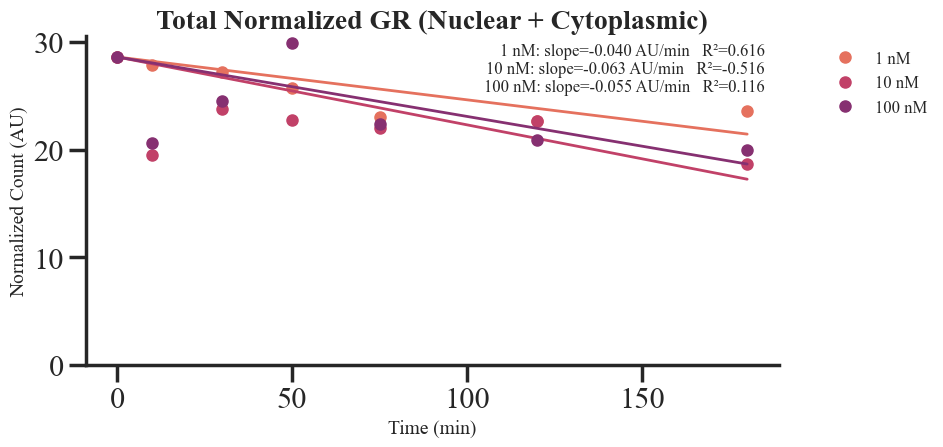

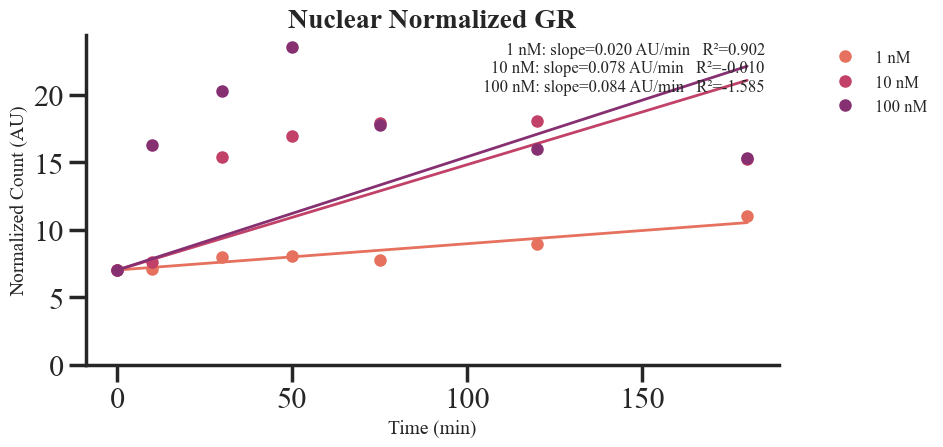

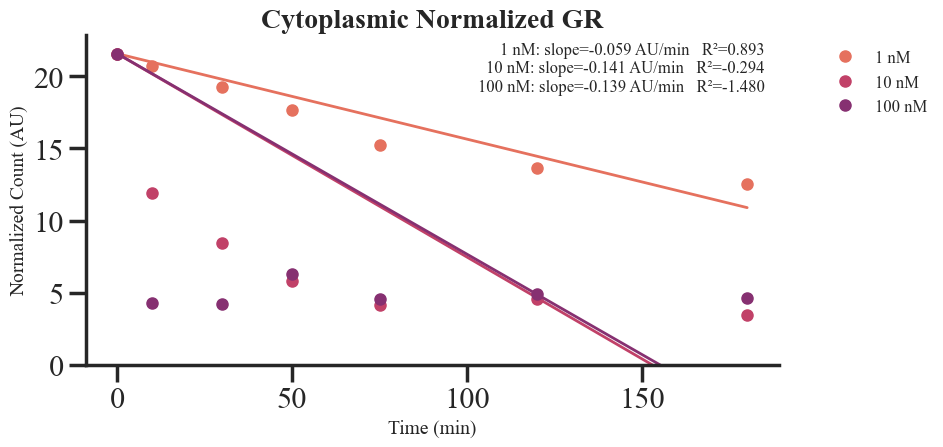

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load data ---
df_gr_gated = pd.read_csv(
    '/Volumes/share/Users/Eric/GR_DUSP1_AllData/FinalAnalysis_GR_DUSP1_Sep18/FinalDataframes_Sep18/GR_SSITcellresults_Final_Sep18.csv'
).copy()

# --- Per-cell totals (raw and normalized) ---
df_gr_gated['TotalGRCorrected'] = df_gr_gated['NucGRCorrected'] + df_gr_gated['CytGRCorrected']
df_gr_gated['normGRtotal']      = df_gr_gated['normGRnuc']      + df_gr_gated['normGRcyt']

# --- Replica-level means ---
replica_means = df_gr_gated.groupby(['dex_conc', 'time', 'replica']).agg({
    'NucGRCorrected'  : 'mean',
    'CytGRCorrected'  : 'mean',
    'TotalGRCorrected': 'mean',
    'normGRnuc'       : 'mean',
    'normGRcyt'       : 'mean',
    'normGRtotal'     : 'mean'
}).reset_index()

# --- Mean of replica means (for plotting points) ---
summary_stats = replica_means.groupby(['dex_conc', 'time']).agg({
    'NucGRCorrected'  : 'mean',
    'CytGRCorrected'  : 'mean',
    'TotalGRCorrected': 'mean',
    'normGRnuc'       : 'mean',
    'normGRcyt'       : 'mean',
    'normGRtotal'     : 'mean'
}).reset_index().rename(columns={
    'NucGRCorrected'  : 'mean_norm_nuc_raw',   # not used for plotting
    'CytGRCorrected'  : 'mean_norm_cyto_raw',  # not used for plotting
    'TotalGRCorrected': 'mean_norm_total_raw', # not used for plotting
    'normGRnuc'       : 'mean_norm_nuc',
    'normGRcyt'       : 'mean_norm_cyto',
    'normGRtotal'     : 'mean_norm_total'
})

# --- Shared 0-min baseline row: dex_conc==0 @ time==0 (fallback if missing) ---
if ((summary_stats['dex_conc'] == 0) & (summary_stats['time'] == 0)).any():
    zero_min_row = summary_stats[(summary_stats['dex_conc'] == 0) & (summary_stats['time'] == 0)].iloc[[0]].copy()
else:
    zero_min_row = summary_stats[summary_stats['time'] == 0].iloc[[0]].copy()

# --- Plotting setup ---
sns.set_theme(style="ticks", context="poster", font='Times New Roman')
palette = sns.color_palette("flare", n_colors=3)
conc_colors = {1: palette[0], 10: palette[1], 100: palette[2]}

# Only plot concentrations > 0
conc_list = [c for c in [1, 10, 100] if c in summary_stats['dex_conc'].unique()]
desired_timepoints = [0, 10, 30, 50, 75, 120, 180]


def plot_component(component_col: str, title: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(10, 5))
    fit_summaries = []

    for conc in conc_list:
        # means for this conc at desired timepoints
        sub = summary_stats[(summary_stats['dex_conc'] == conc) &
                            (summary_stats['time'].isin(desired_timepoints))].copy()

        # append the shared 0-min baseline row (relabel conc)
        sub = pd.concat([zero_min_row.assign(dex_conc=conc), sub], ignore_index=True)

        # keep only time + the component we’re plotting
        sub = sub[['time', component_col]].dropna().drop_duplicates().sort_values('time')

        # scatter (means only)
        ax.plot(sub['time'], sub[component_col], 'o',
                color=conc_colors[conc], label=f'{conc} nM', markersize=8)

        # ----- FIXED-INTERCEPT LINEAR FIT (forces line through 0-min) -----
        x = sub['time'].to_numpy(dtype=float)
        y = sub[component_col].to_numpy(dtype=float)

        # y0 is the 0-min control value; sub includes it because we appended it
        if (sub['time'] == 0).any():
            y0 = float(sub.loc[sub['time'] == 0, component_col].iloc[0])
        else:
            # fallback (shouldn't trigger given the concat above)
            y0 = float(zero_min_row[component_col].iloc[0])

        # Use only x>0 for slope estimation; require at least one positive timepoint
        mask_pos = x > 0
        if mask_pos.sum() >= 1:
            denom = np.sum(x[mask_pos] ** 2)
            if denom > 0:
                m = np.sum(x[mask_pos] * (y[mask_pos] - y0)) / denom
                b = y0

                xx = np.linspace(min(desired_timepoints), max(desired_timepoints), 200)
                ax.plot(xx, y0 + m * xx, '-', color=conc_colors[conc], linewidth=2)

                yhat = y0 + m * x
                ss_res = np.sum((y - yhat) ** 2)
                ss_tot = np.sum((y - y.mean()) ** 2)
                r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
                fit_summaries.append((conc, m, r2))
            else:
                # all positive x are zero-length after squaring (shouldn't happen)
                pass
        # ------------------------------------------------------------------

    # styling
    ax.set_title(title, fontsize=20, fontweight='bold')
    ax.set_xlabel('Time (min)', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_ylim(bottom=0)
    sns.despine(ax=ax)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, frameon=False)

    # slope & R² box
    if fit_summaries:
        lines = [f"{conc} nM: slope={m:.3f} AU/min   R²={r2:.3f}" for conc, m, r2 in fit_summaries]
        ax.text(0.98, 0.98, "\n".join(lines), transform=ax.transAxes,
                ha='right', va='top', fontsize=12)
    else:
        ax.text(0.98, 0.98, "Insufficient points for fit", transform=ax.transAxes,
                ha='right', va='top', fontsize=12)

    plt.tight_layout()
    plt.show()


# --- Plot 1: Total Normalized GR ---
plot_component('mean_norm_total',
               'Total Normalized GR (Nuclear + Cytoplasmic)',
               'Normalized Count (AU)')

# --- Plot 2: Nuclear Normalized GR ---
plot_component('mean_norm_nuc',
               'Nuclear Normalized GR',
               'Normalized Count (AU)')

# --- Plot 3: Cytoplasmic Normalized GR ---
plot_component('mean_norm_cyto',
               'Cytoplasmic Normalized GR',
               'Normalized Count (AU)')

In [ ]:
# =============================
# A) Inspect 100 nM replicates
# =============================

# How many replicates at each time for 100 nM?
print("Replicate counts @100 nM (per time):")
print(
    replica_means.query("dex_conc == 100")
    .groupby('time')['replica'].nunique()
    .sort_index()
)

# 1) Overlay replicate curves for Total Normalized GR @100 nM
plt.figure(figsize=(10,5))
for rep in sorted(replica_means['replica'].unique()):
    sub = replica_means.query("dex_conc == 100 and replica == @rep")[['time','normGRtotal']].sort_values('time')
    if len(sub) > 0:
        plt.plot(sub['time'], sub['normGRtotal'], 'o-', alpha=0.6, linewidth=1.8, label=f'Rep {rep}')
plt.title("100 nM – Total Normalized GR by replicate")
plt.xlabel("Time (min)")
plt.ylabel("Normalized Count (AU)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, frameon=False)
plt.tight_layout()
plt.show()

# 2) Overlay replicate curves for RAW Total Corrected GR @100 nM
plt.figure(figsize=(10,5))
for rep in sorted(replica_means['replica'].unique()):
    sub = replica_means.query("dex_conc == 100 and replica == @rep")[['time','TotalGRCorrected']].sort_values('time')
    if len(sub) > 0:
        plt.plot(sub['time'], sub['TotalGRCorrected'], 'o-', alpha=0.6, linewidth=1.8, label=f'Rep {rep}')
plt.title("100 nM – RAW Total GR (Corrected) by replicate")
plt.xlabel("Time (min)")
plt.ylabel("Intensity (AU)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, frameon=False)
plt.tight_layout()
plt.show()

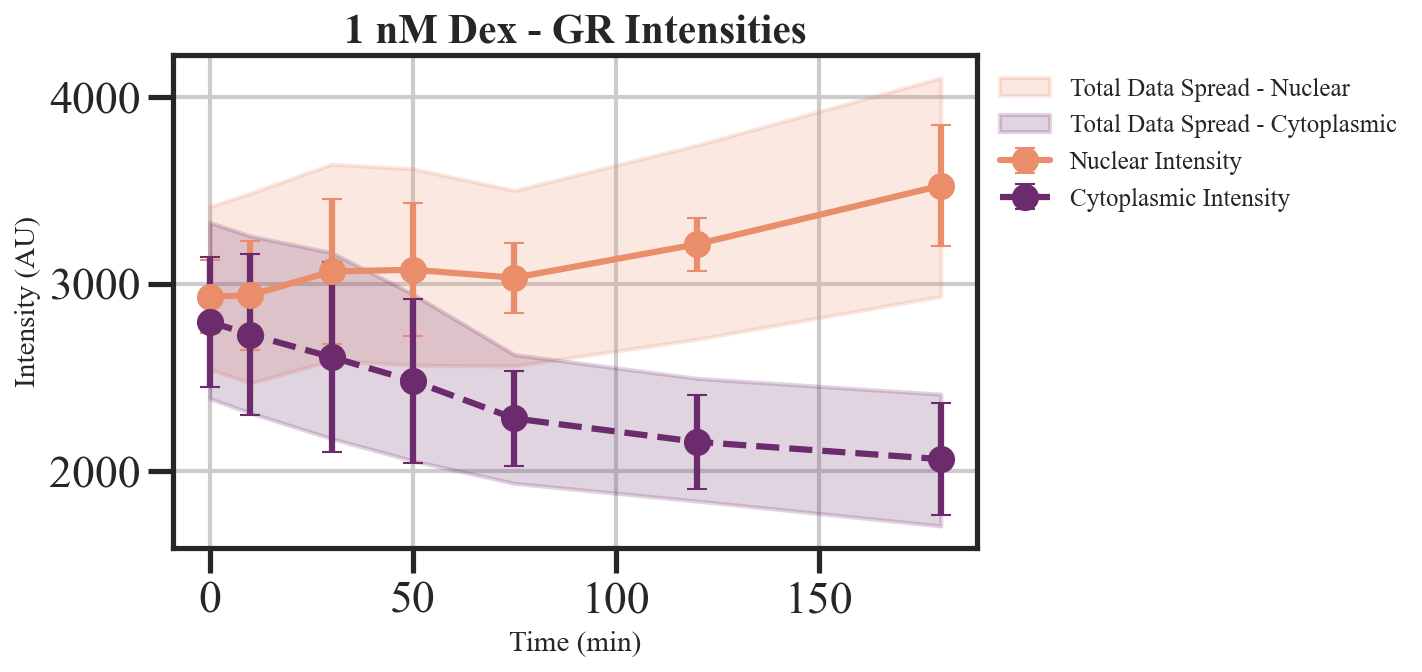

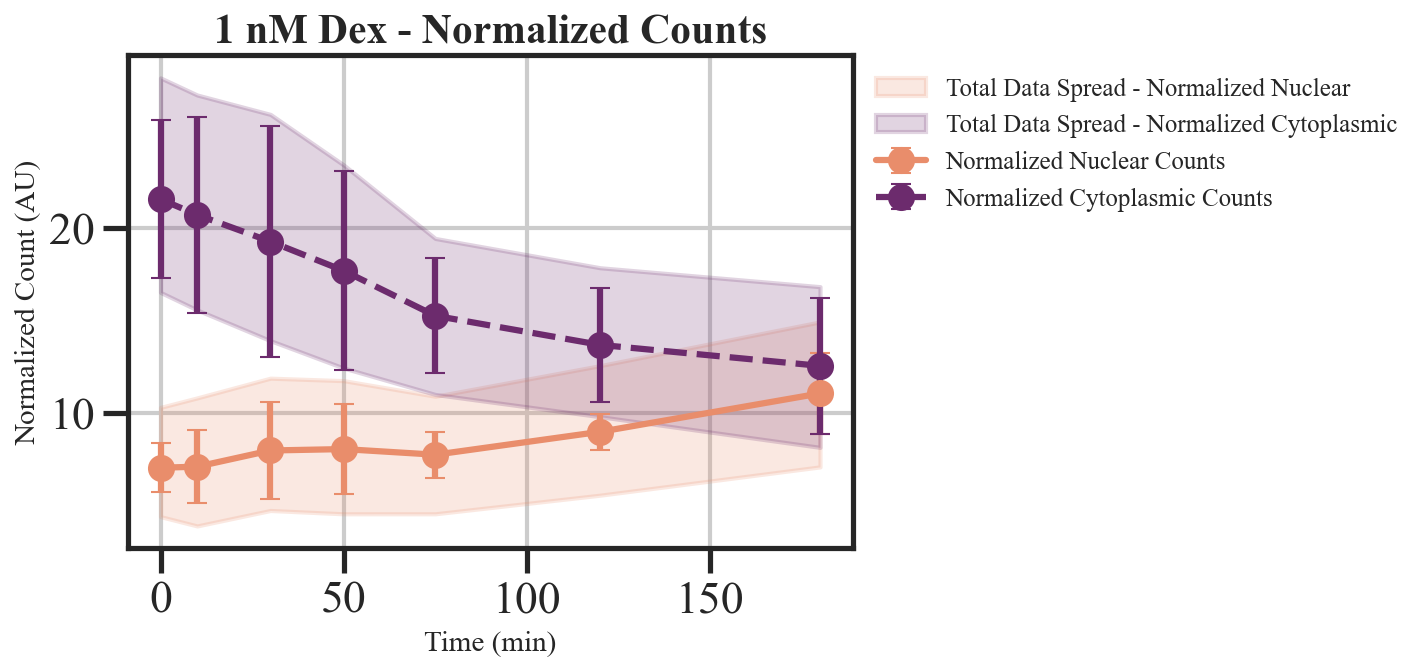

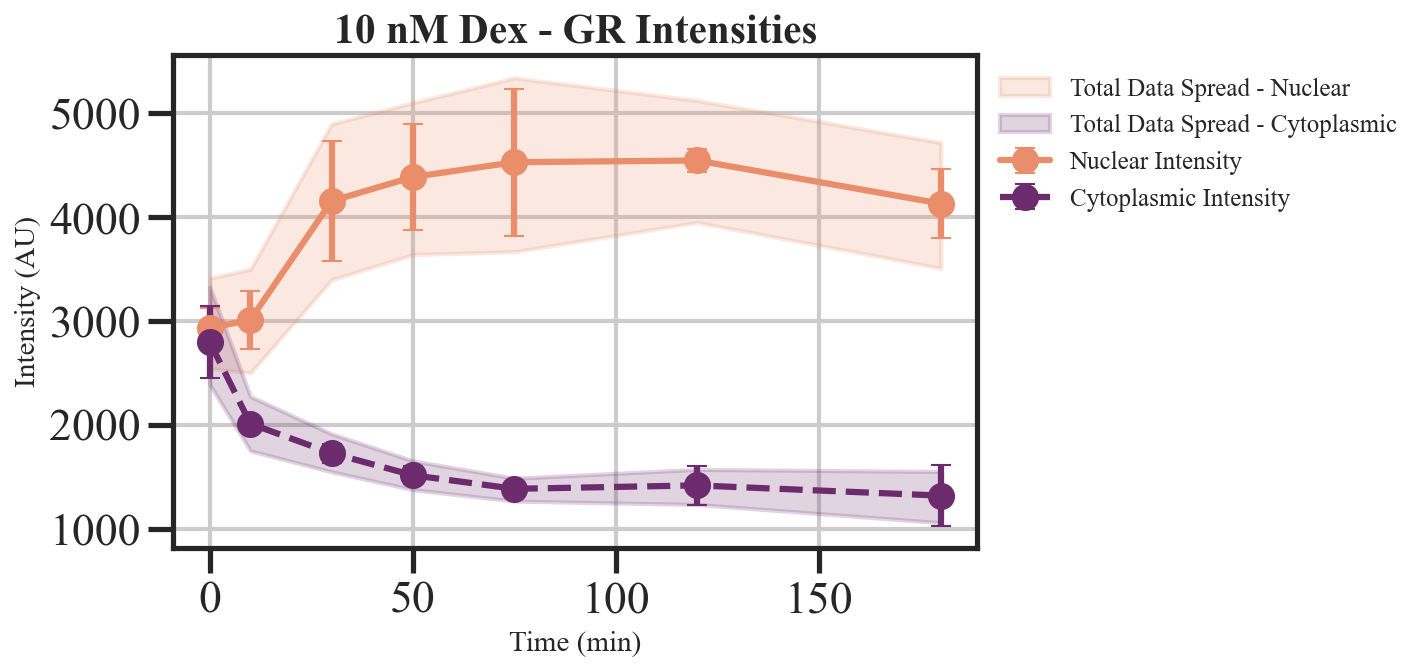

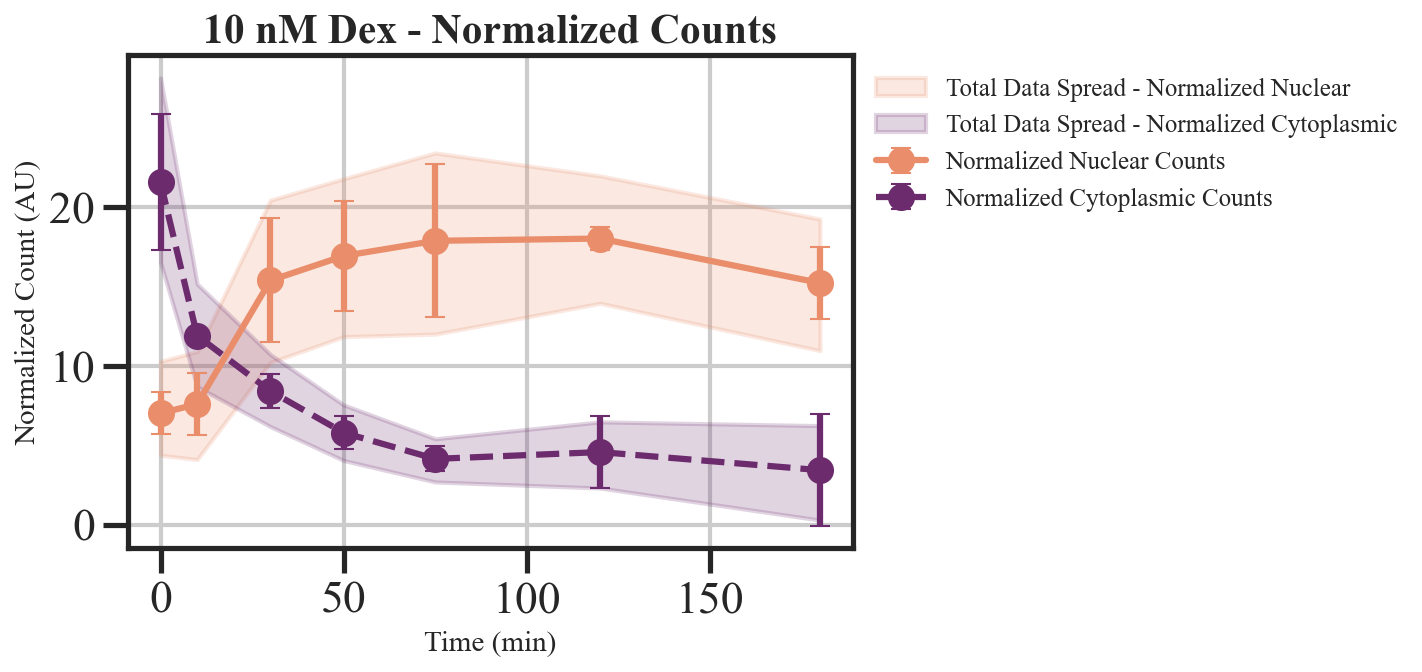

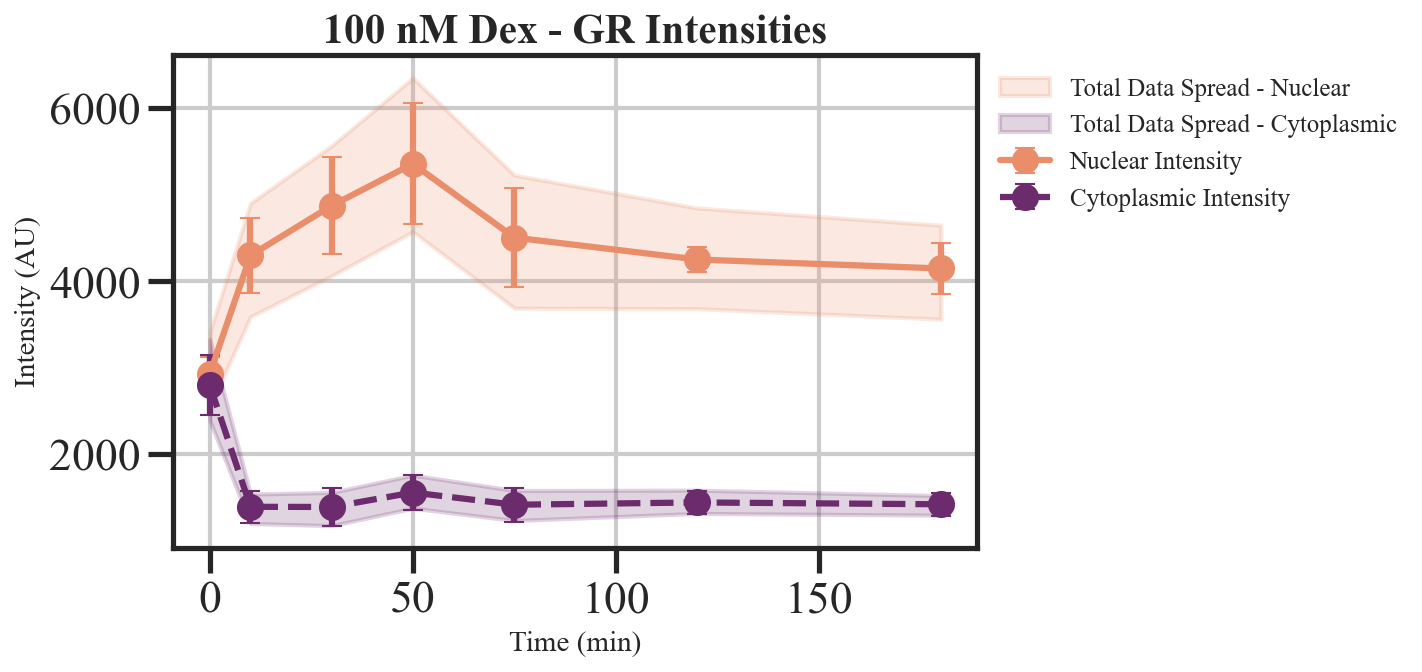

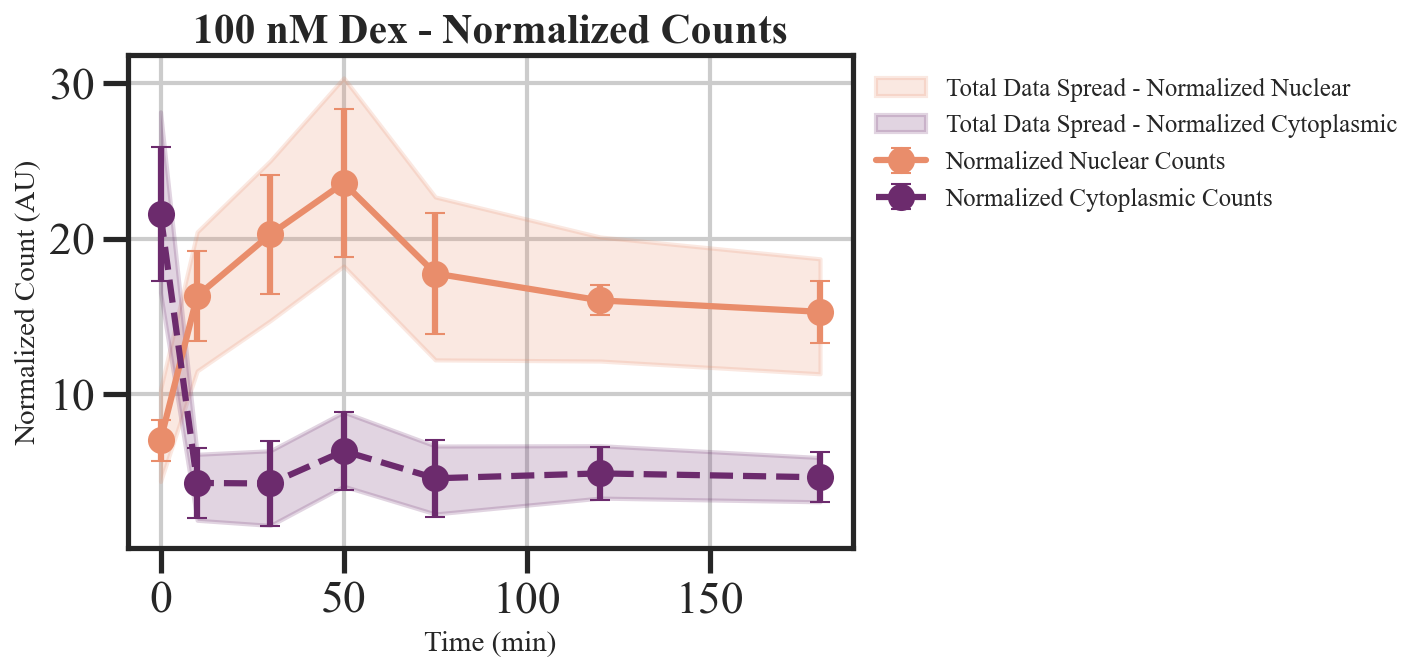

In [12]:
# GR Summary Statistics + Plots

df_gr_gated = pd.read_csv(f'/Volumes/share/Users/Eric/GR_DUSP1_AllData/FinalAnalysis_GR_DUSP1_Sep18/FinalDataframes_Sep18/GR_SSITcellresults_Final_Sep18.csv').copy()

# Calculate means for each replica
replica_means = df_gr_gated.groupby(['dex_conc', 'time', 'replica']).agg({
    'NucGRCorrected': 'mean',
    'CytGRCorrected': 'mean',
    'normGRnuc': 'mean',
    'normGRcyt': 'mean'
}).reset_index()

# Calculate the mean and standard deviation of the replica means
summary_stats = replica_means.groupby(['dex_conc', 'time']).agg({
    'NucGRCorrected': ['mean', 'std'],
    'CytGRCorrected': ['mean', 'std'],
    'normGRnuc': ['mean', 'std'],
    'normGRcyt': ['mean', 'std']
}).reset_index()

# Rename columns for easier access
summary_stats.columns = ['dex_conc', 'time', 'mean_nuc_int', 'std_nuc_int', 'mean_cyto_int', 'std_cyto_int', 'mean_norm_nuc', 'std_norm_nuc', 'mean_norm_cyto', 'std_norm_cyto']

# Calculate overall mean and standard deviation for each concentration and time point
overall_stats = df_gr_gated.groupby(['dex_conc', 'time']).agg({
    'NucGRCorrected': ['mean', 'std'],
    'CytGRCorrected': ['mean', 'std'],
    'normGRnuc': ['mean', 'std'],
    'normGRcyt': ['mean', 'std']
}).reset_index()

# Rename columns for easier access
overall_stats.columns = ['dex_conc', 'time', 'overall_mean_nuc', 'overall_std_nuc', 'overall_mean_cyto', 'overall_std_cyto', 'overall_mean_norm_nuc', 'overall_std_norm_nuc', 'overall_mean_norm_cyto', 'overall_std_norm_cyto']

# Extract 0 min data (shared baseline from dex_conc == 0)
zero_min_summary = summary_stats[summary_stats['time'] == 0]
zero_min_overall = overall_stats[overall_stats['time'] == 0]

# Set Seaborn Theme
sns.set_theme(style="ticks", palette="flare", context="poster", font='Times New Roman')

# Define color palette
palette = sns.color_palette("flare", as_cmap=False)
colors_nuc_cyto = [palette[0], palette[-1]]  # Nuclear = First Color, Cytoplasmic = Last Color

# Define the desired time points
desired_timepoints = [0, 10, 30, 50, 75, 120, 180]

for conc in [1, 10, 100]:
    # Filter data for plotting
    subset_summary = summary_stats[(summary_stats['dex_conc'] == conc) & (summary_stats['time'].isin(desired_timepoints))]
    subset_overall = overall_stats[(overall_stats['dex_conc'] == conc) & (overall_stats['time'].isin(desired_timepoints))]

    # Add 0 min time point to all subsets
    subset_summary = pd.concat([zero_min_summary, subset_summary], ignore_index=True)
    subset_overall = pd.concat([zero_min_overall, subset_overall], ignore_index=True)

    ### **PLOT 1: INTENSITY PLOTS (NUCLEAR & CYTOPLASMIC)**
    plt.figure(figsize=(10, 5))

    # Nuclear Intensity
    plt.errorbar(subset_summary['time'], subset_summary['mean_nuc_int'],
                 yerr=subset_summary['std_nuc_int'], fmt='-o', color=colors_nuc_cyto[0], capsize=5,
                 label='Nuclear Intensity')

    # Shaded area for Nuclear Total Variability
    plt.fill_between(subset_overall['time'],
                     subset_overall['overall_mean_nuc'] - subset_overall['overall_std_nuc'],
                     subset_overall['overall_mean_nuc'] + subset_overall['overall_std_nuc'],
                     color=colors_nuc_cyto[0], alpha=0.2, label='Total Data Spread - Nuclear')

    # Cytoplasmic Intensity
    plt.errorbar(subset_summary['time'], subset_summary['mean_cyto_int'],
                 yerr=subset_summary['std_cyto_int'], fmt='--o', color=colors_nuc_cyto[1], capsize=5,
                 label='Cytoplasmic Intensity')

    # Shaded area for Cytoplasmic Total Variability
    plt.fill_between(subset_overall['time'],
                     subset_overall['overall_mean_cyto'] - subset_overall['overall_std_cyto'],
                     subset_overall['overall_mean_cyto'] + subset_overall['overall_std_cyto'],
                     color=colors_nuc_cyto[1], alpha=0.2, label='Total Data Spread - Cytoplasmic')

    # Customize plot
    plt.title(f'{conc} nM Dex - GR Intensities', fontsize=20, fontweight='bold')
    plt.xlabel('Time (min)', fontsize=14)
    plt.ylabel('Intensity (AU)', fontsize=14)
    plt.grid(True)
    plt.legend(loc='upper left', fontsize=12, frameon=False, bbox_to_anchor=(1, 1))

    plt.show()

    ### **PLOT 2: NORMALIZED COUNTS PLOTS (NUCLEAR & CYTOPLASMIC)**
    plt.figure(figsize=(10, 5))

    # Nuclear Normalized Counts
    plt.errorbar(subset_summary['time'], subset_summary['mean_norm_nuc'],
                 yerr=subset_summary['std_norm_nuc'], fmt='-o', color=colors_nuc_cyto[0], capsize=5,
                 label='Normalized Nuclear Counts')

    # Shaded area for Nuclear Normalized Total Variability
    plt.fill_between(subset_overall['time'],
                     subset_overall['overall_mean_norm_nuc'] - subset_overall['overall_std_norm_nuc'],
                     subset_overall['overall_mean_norm_nuc'] + subset_overall['overall_std_norm_nuc'],
                     color=colors_nuc_cyto[0], alpha=0.2, label='Total Data Spread - Normalized Nuclear')

    # Cytoplasmic Normalized Counts
    plt.errorbar(subset_summary['time'], subset_summary['mean_norm_cyto'],
                 yerr=subset_summary['std_norm_cyto'], fmt='--o', color=colors_nuc_cyto[1], capsize=5,
                 label='Normalized Cytoplasmic Counts')

    # Shaded area for Cytoplasmic Normalized Total Variability
    plt.fill_between(subset_overall['time'],
                     subset_overall['overall_mean_norm_cyto'] - subset_overall['overall_std_norm_cyto'],
                     subset_overall['overall_mean_norm_cyto'] + subset_overall['overall_std_norm_cyto'],
                     color=colors_nuc_cyto[1], alpha=0.2, label='Total Data Spread - Normalized Cytoplasmic')

    # Customize plot
    plt.title(f'{conc} nM Dex - Normalized Counts', fontsize=20, fontweight='bold')
    plt.xlabel('Time (min)', fontsize=14)
    plt.ylabel('Normalized Count (AU)', fontsize=14)
    plt.grid(True)
    plt.legend(loc='upper left', fontsize=12, frameon=False, bbox_to_anchor=(1, 1))

    plt.show()

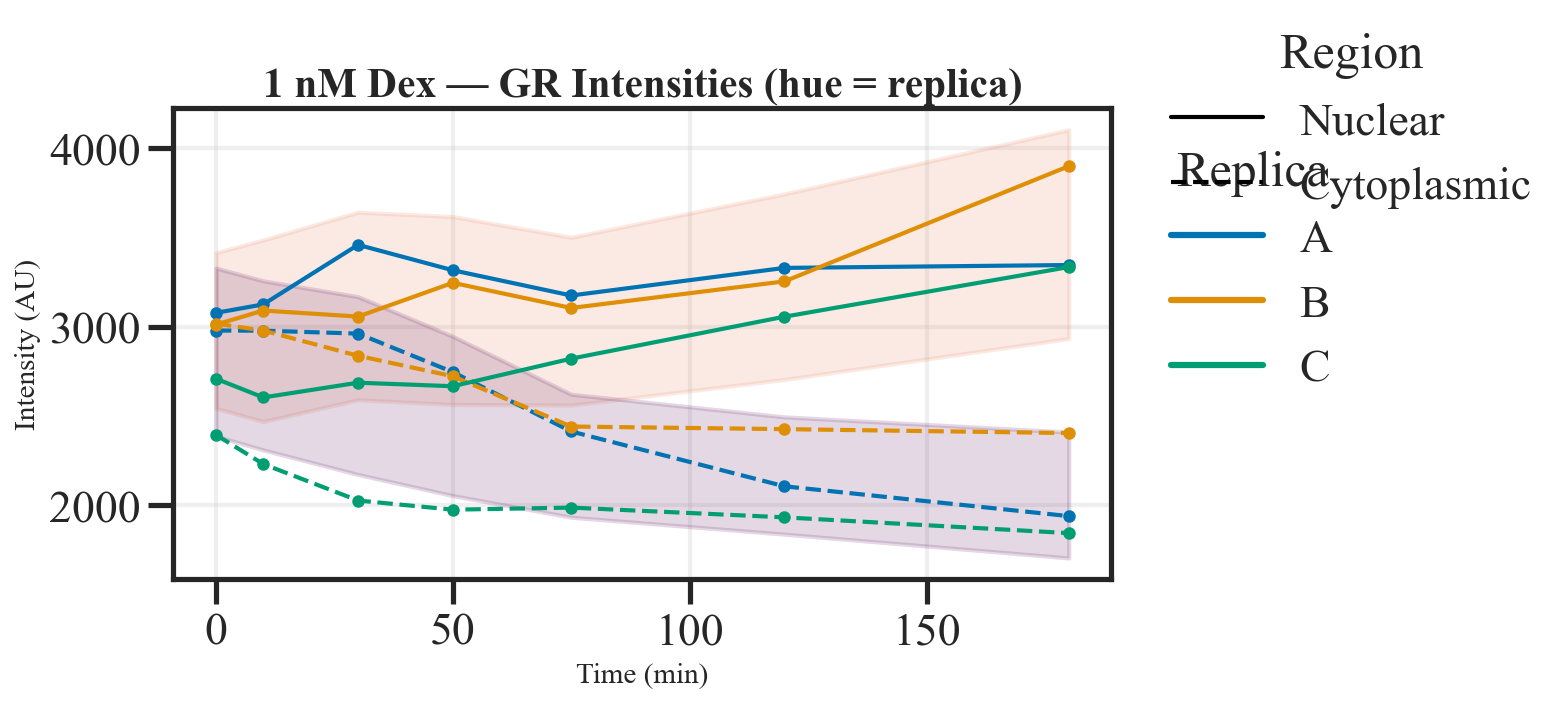

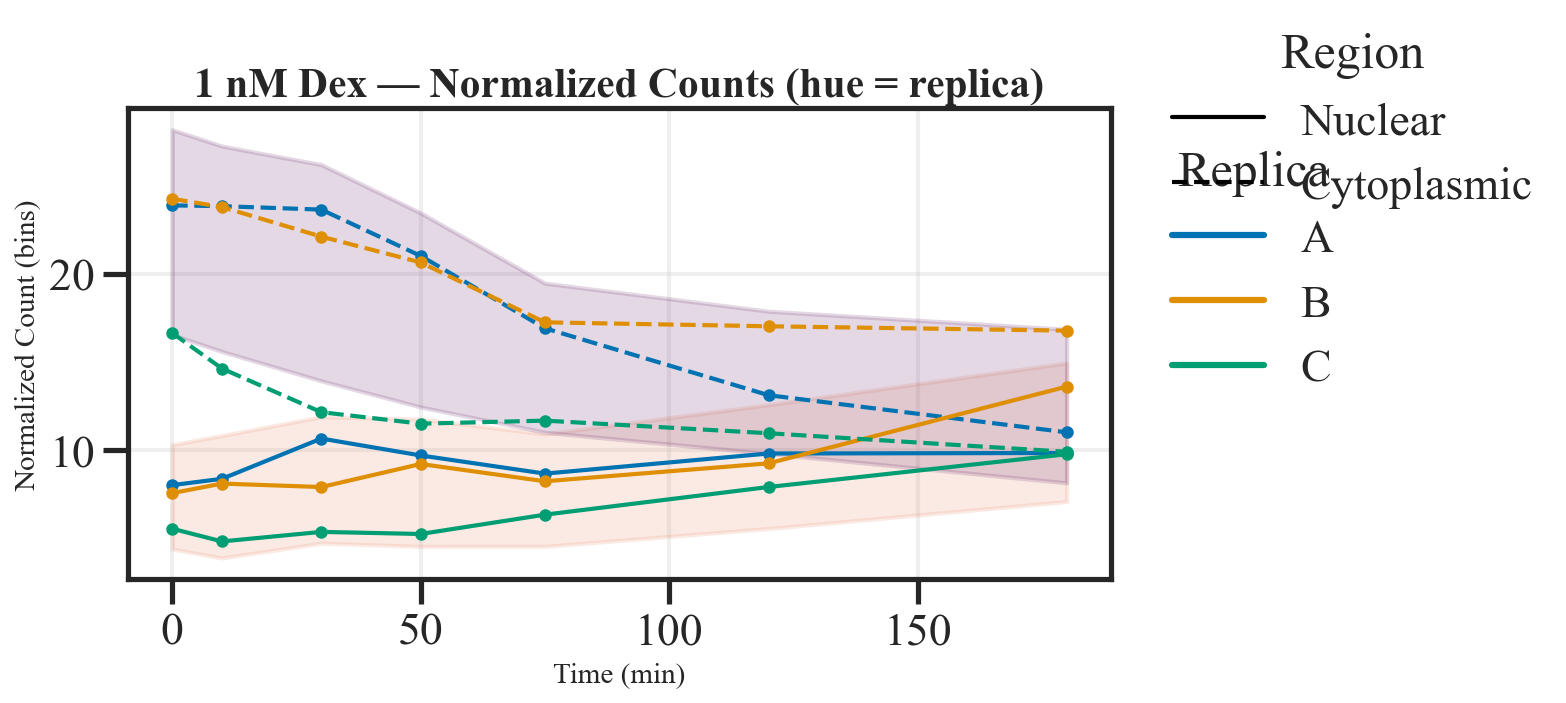

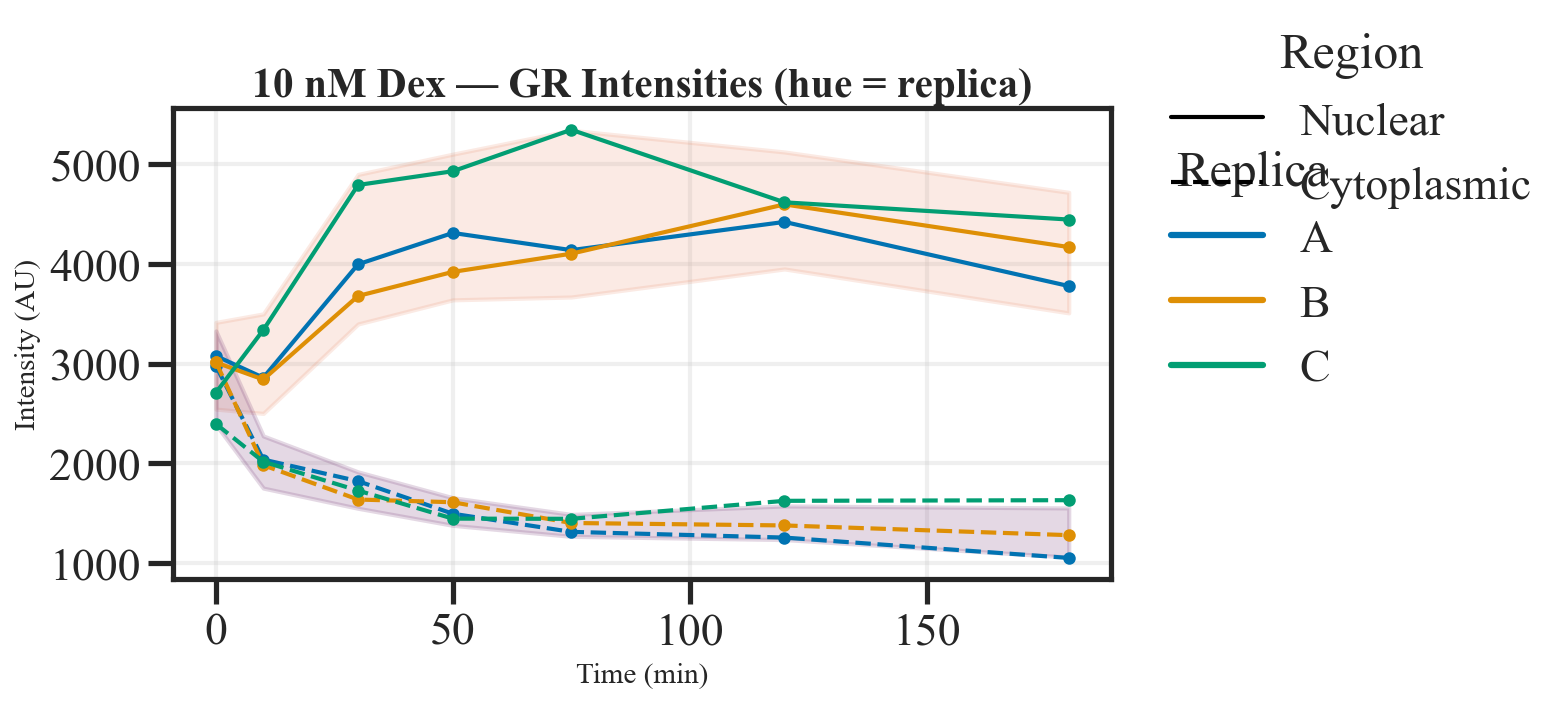

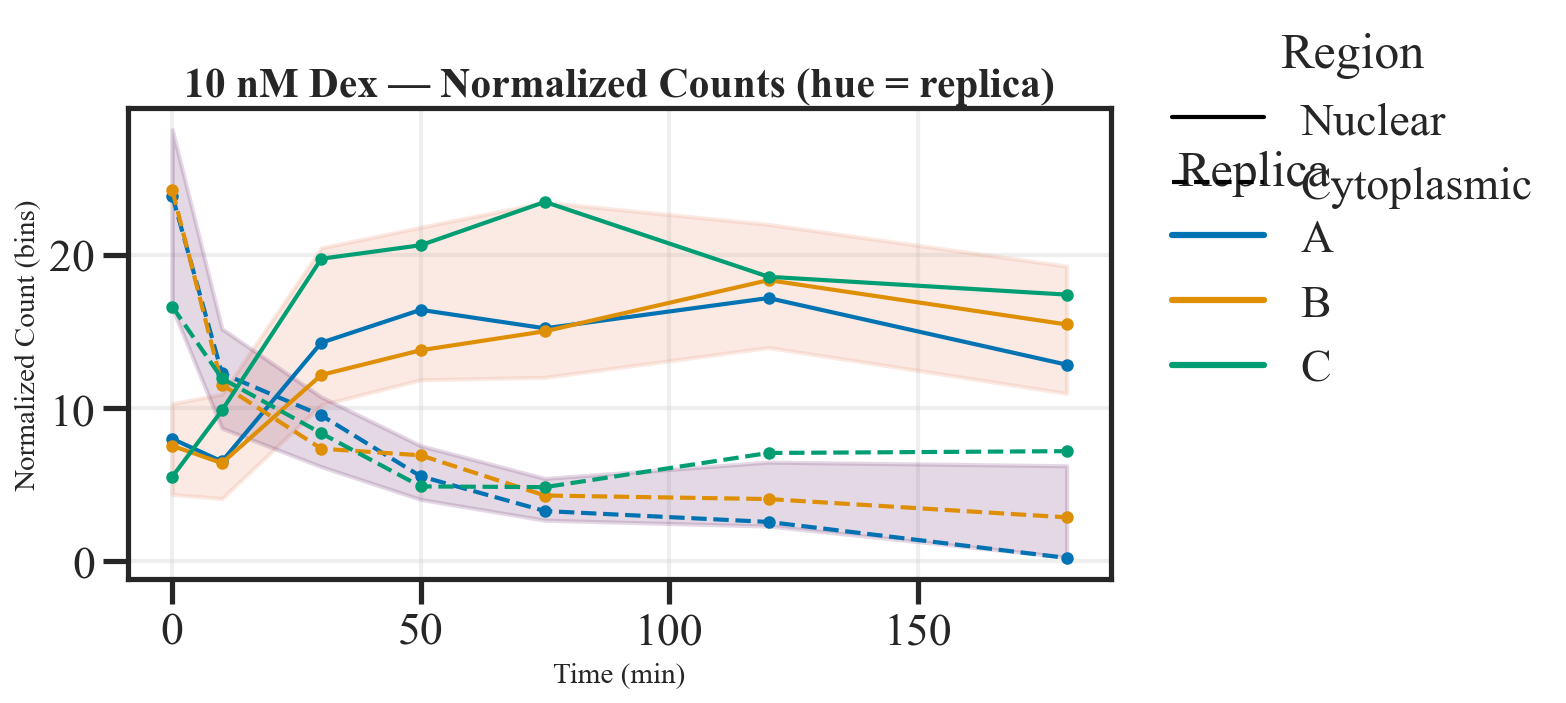

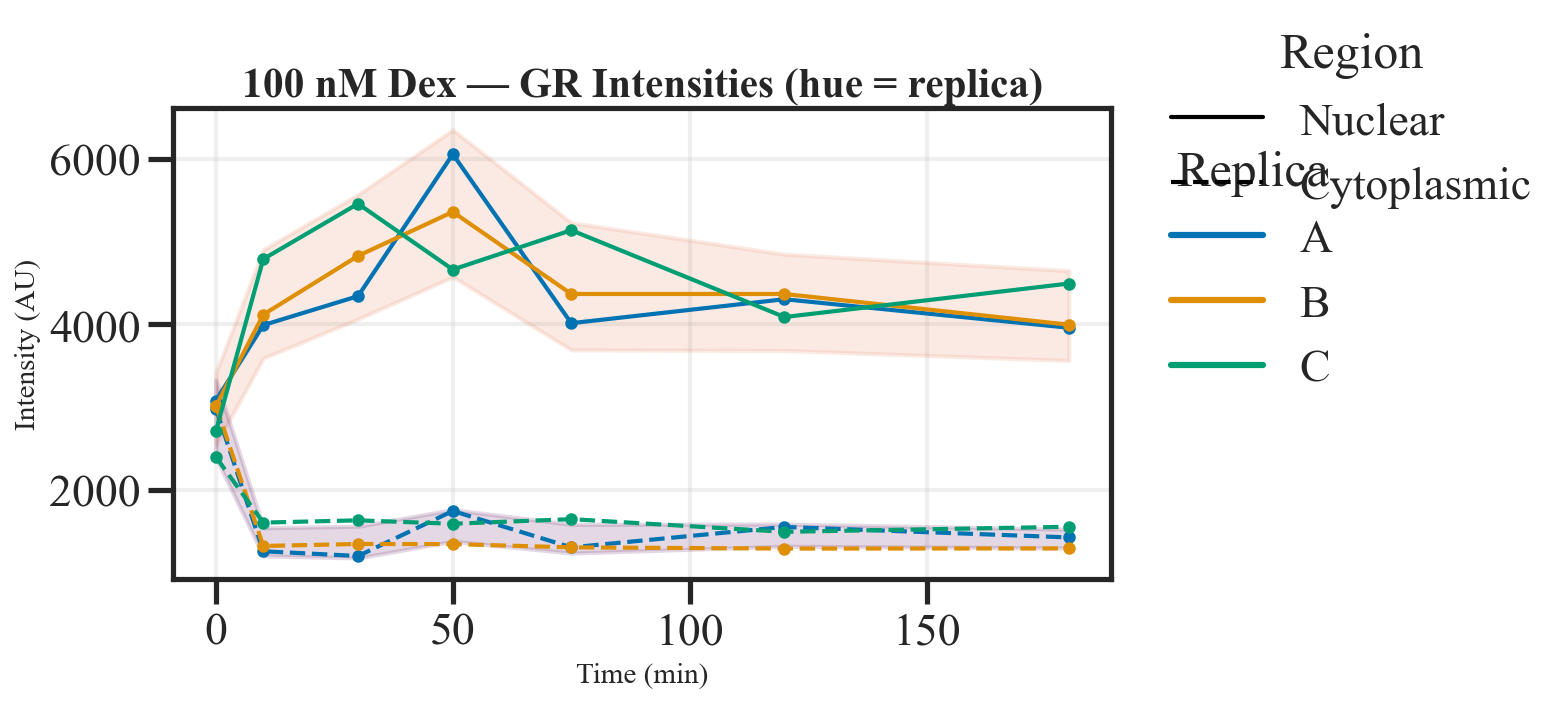

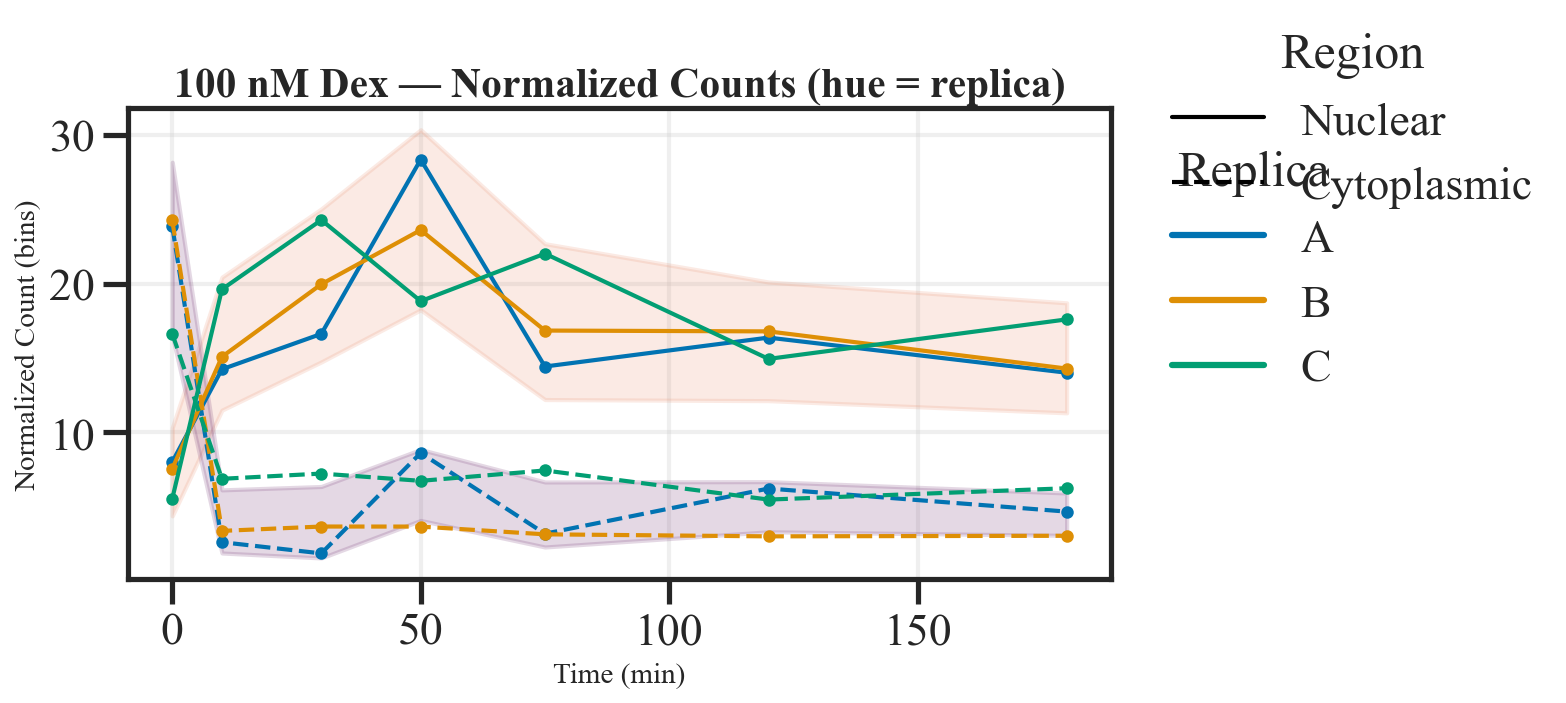

In [11]:
# =========================
# GR Summary Statistics + Plots (hue = replica)
# =========================

# --- Per-replica means (lines) ---
replica_means = df_gr_gated.groupby(['dex_conc', 'time', 'replica'], as_index=False).agg({
    'NucGRCorrected': 'mean',
    'CytGRCorrected': 'mean',
    'normGRnuc': 'mean',
    'normGRcyt': 'mean'
})
replica_means['replica'] = replica_means['replica'].astype(str)

# --- Overall stats (shaded bands) ---
overall_stats = df_gr_gated.groupby(['dex_conc', 'time'], as_index=False).agg({
    'NucGRCorrected': ['mean', 'std'],
    'CytGRCorrected': ['mean', 'std'],
    'normGRnuc': ['mean', 'std'],
    'normGRcyt': ['mean', 'std']
})
overall_stats.columns = ['dex_conc','time',
                         'overall_mean_nuc','overall_std_nuc',
                         'overall_mean_cyto','overall_std_cyto',
                         'overall_mean_norm_nuc','overall_std_norm_nuc',
                         'overall_mean_norm_cyto','overall_std_norm_cyto']

# --- Common 0-min baseline per replica from dex_conc==0 ---
zero_rep = replica_means.query('time == 0 and dex_conc == 0').copy()

# Theme
sns.set_theme(style="ticks", palette="colorblind", context="poster", font='Times New Roman')

# Hue palette for replicas
rep_order   = sorted(replica_means['replica'].unique())
rep_palette = dict(zip(rep_order, sns.color_palette("colorblind", len(rep_order))))

# Colors for shaded overall bands (keep your flare endpoints for contrast)
palette = sns.color_palette("flare", as_cmap=False)
colors_nuc_cyto = [palette[0], palette[-1]]  # nuclear, cytoplasmic

desired_timepoints = [0, 10, 30, 50, 75, 120, 180]

for conc in [1, 10, 100]:
    # -------- Build plotting frames --------
    # Per-rep lines for this conc (exclude time 0 here; we'll inject shared baseline)
    sub_rep = replica_means.query('dex_conc == @conc and time in @desired_timepoints and time != 0').copy()

    # Duplicate baseline rows into this concentration for all replicas that exist at baseline
    base = zero_rep.copy()
    base['dex_conc'] = conc
    # Keep only replicas that appear in this conc (if you want *all* baseline replicas regardless, drop the merge)
    if not sub_rep.empty:
        present_reps = set(sub_rep['replica'].unique())
        base = base[base['replica'].isin(present_reps)]
    sub_rep = pd.concat([base, sub_rep], ignore_index=True)

    # Overall bands for this conc (+ 0-min from dex_conc==0 merged in)
    sub_overall = overall_stats.query('dex_conc == @conc and time in @desired_timepoints and time != 0').copy()
    base_overall = overall_stats.query('dex_conc == 0 and time == 0').copy()
    base_overall = base_overall.assign(dex_conc=conc)
    sub_overall = pd.concat([base_overall, sub_overall], ignore_index=True)

    # Sort for pretty lines
    sub_rep.sort_values(['replica','time'], inplace=True)
    sub_overall.sort_values('time', inplace=True)

    # ===============================
    # PLOT 1: Corrected Intensities
    # ===============================
    plt.figure(figsize=(11, 5))

    # Shaded overall bands (nuclear, cytoplasmic)
    plt.fill_between(sub_overall['time'],
                     sub_overall['overall_mean_nuc'] - sub_overall['overall_std_nuc'],
                     sub_overall['overall_mean_nuc'] + sub_overall['overall_std_nuc'],
                     color=colors_nuc_cyto[0], alpha=0.18, label='Overall ±1 SD (Nuclear)')
    plt.fill_between(sub_overall['time'],
                     sub_overall['overall_mean_cyto'] - sub_overall['overall_std_cyto'],
                     sub_overall['overall_mean_cyto'] + sub_overall['overall_std_cyto'],
                     color=colors_nuc_cyto[1], alpha=0.18, label='Overall ±1 SD (Cytoplasmic)')

    # Per-replica lines: solid = nuclear, dashed = cytoplasmic
    for rep in rep_order:
        df_r = sub_rep[sub_rep['replica'] == rep]
        if df_r.empty:
            continue
        c = rep_palette[rep]
        plt.plot(df_r['time'], df_r['NucGRCorrected'], '-o', color=c, linewidth=2, markersize=5, label=f'{rep} (Nuc)')
        plt.plot(df_r['time'], df_r['CytGRCorrected'], '--o', color=c, linewidth=2, markersize=5, label=f'{rep} (Cyto)')

    plt.title(f'{conc} nM Dex — GR Intensities (hue = replica)', fontsize=20, fontweight='bold')
    plt.xlabel('Time (min)', fontsize=14)
    plt.ylabel('Intensity (AU)', fontsize=14)
    plt.grid(True, alpha=0.3)

    # Build compact legends: one for replicas (colors), one for line styles (region)
    # 1) Replica color legend
    rep_handles = [plt.Line2D([0],[0], color=rep_palette[r], lw=3) for r in rep_order]
    rep_labels  = rep_order
    # 2) Region style legend
    style_handles = [
        plt.Line2D([0],[0], color='black', lw=2, ls='-'),
        plt.Line2D([0],[0], color='black', lw=2, ls='--')
    ]
    style_labels = ['Nuclear', 'Cytoplasmic']

    first_legend = plt.legend(rep_handles, rep_labels, title='Replica', loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
    plt.gca().add_artist(first_legend)
    plt.legend(style_handles, style_labels, title='Region', loc='lower left', bbox_to_anchor=(1.02, 0.70), frameon=False)

    plt.tight_layout()
    plt.show()

    # =================================
    # PLOT 2: Normalized Counts (bins)
    # =================================
    plt.figure(figsize=(11, 5))

    # Shaded overall bands (normalized)
    plt.fill_between(sub_overall['time'],
                     sub_overall['overall_mean_norm_nuc'] - sub_overall['overall_std_norm_nuc'],
                     sub_overall['overall_mean_norm_nuc'] + sub_overall['overall_std_norm_nuc'],
                     color=colors_nuc_cyto[0], alpha=0.18, label='Overall ±1 SD (Norm Nuclear)')
    plt.fill_between(sub_overall['time'],
                     sub_overall['overall_mean_norm_cyto'] - sub_overall['overall_std_norm_cyto'],
                     sub_overall['overall_mean_norm_cyto'] + sub_overall['overall_std_norm_cyto'],
                     color=colors_nuc_cyto[1], alpha=0.18, label='Overall ±1 SD (Norm Cytoplasmic)')

    # Per-replica lines (no truncation; these can exceed 30 per your new discretizer)
    for rep in rep_order:
        df_r = sub_rep[sub_rep['replica'] == rep]
        if df_r.empty:
            continue
        c = rep_palette[rep]
        plt.plot(df_r['time'], df_r['normGRnuc'], '-o',  color=c, linewidth=2, markersize=5, label=f'{rep} (Norm Nuc)')
        plt.plot(df_r['time'], df_r['normGRcyt'], '--o', color=c, linewidth=2, markersize=5, label=f'{rep} (Norm Cyto)')

    plt.title(f'{conc} nM Dex — Normalized Counts (hue = replica)', fontsize=20, fontweight='bold')
    plt.xlabel('Time (min)', fontsize=14)
    plt.ylabel('Normalized Count (bins)', fontsize=14)
    plt.grid(True, alpha=0.3)

    # Legends as above
    first_legend = plt.legend(rep_handles, rep_labels, title='Replica', loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
    plt.gca().add_artist(first_legend)
    plt.legend(style_handles, style_labels, title='Region', loc='lower left', bbox_to_anchor=(1.02, 0.70), frameon=False)

    plt.tight_layout()
    plt.show()